In [3]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numba
import tqdm
import scipy
import os
import sys
import joblib
import scanpy as sc
import os
import itertools
from itertools import product
from collections import defaultdict
from itertools import combinations
from scipy.stats import mannwhitneyu
from pathlib import Path
from adjustText import adjust_text
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Rectangle
import json

In [4]:
# Calculation functions
import importlib
import sys
import os

from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)

from TwINFER_function_scripts.correlation_analysis_functions import (

    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_cross_correlations,
    identify_actual_directed_edges
)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data,
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

### Plot formatting

In [5]:
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    "/home/gzu5140/Font/Arial.ttf",
    "/home/gzu5140/Font/Arial Bold.ttf",
    "/home/gzu5140/Font/Arial Italic.ttf",
    "/home/gzu5140/Font/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

# ==== LaTeX + SVG text mode (Illustrator-safe) ====
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18     # x/y labels
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12    # legend text

✔ Loaded font: /home/gzu5140/Font/Arial.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold Italic.ttf


### Path to data and output folders

In [20]:
data_path = "/home/gzu5140/Keerthana_b1042/grnInference/real_data/Larry_data/"
path_to_plots = f"/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_5/"
os.makedirs(path_to_plots, exist_ok=True)
path_to_plot_data = Path("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/figure_5/")
path_to_plot_data.mkdir(exist_ok=True)

/home/gzu5140/.conda/envs/twinfer/lib/python3.12/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


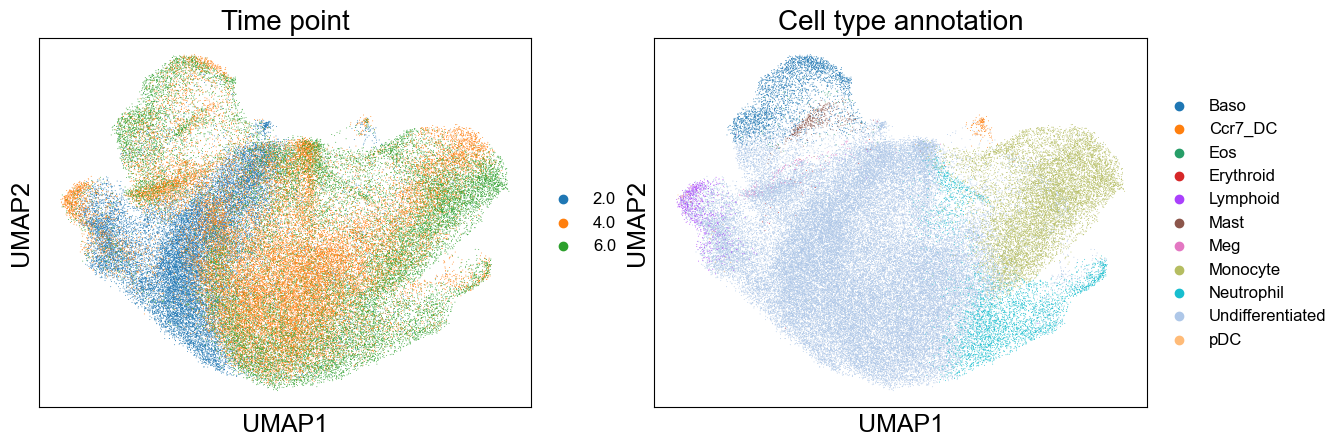

In [7]:
#Load the h5ad file
# Define the full path to the data file
file_path = f'{data_path}LSK_d2_d4_d6.h5ad'

adata = sc.read_h5ad(file_path)
adata.obs_names_make_unique()
# Plot UMAP
sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])

### Genes of interest
- Neutrophil DEG from LARRY
- Monocyte DEG from LARRY
- TF involved in hematopoiesis from the 2011 paper

In [8]:
gene_list_Neutrophil = ['Muc13', 'Srgn', 'Ccl9', 'Plac8', 'Snrpf','Prtn3','Elane', 'Igfbp4', 'Ap3s1', 'Ctsg'] #Neutrophil
gene_list_Monocyte = ['Rbms1', 'Tuba1b','Sirpa', 'Ttf1', 'H3f3b', 'Set', 'Tk1', 'Fkbp4', 'Hspd1', 'Emb'] #Monocyte
gene_list_Regulator_TF = ['Gata1', 'Gata2', 'Gfi1b', 'Fli1', 'Spi1', 'Tal1',  'Cebpa', 'Jun', 'Egr1', 'Nab2', 'Klf1', 'Zfpm1'] #TF involved in hematopoiesis regulation
gene_list_Pertubation = ['Brd9', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Gps2', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']

In [9]:
#Check that all of these genes are present in the dataset (since sometimes they have alternate names. E.g. Pu1 is names Spi1)
gene_list_check = gene_list_Neutrophil + gene_list_Monocyte + gene_list_Regulator_TF + gene_list_Pertubation

all_genes = {g.lower() for g in adata.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)

print("❌ Not found in dataset", not_found)

Found 73 genes out of 73
✅ Found gene(s): ['muc13', 'srgn', 'ccl9', 'plac8', 'snrpf', 'prtn3', 'elane', 'igfbp4', 'ap3s1', 'ctsg', 'rbms1', 'tuba1b', 'sirpa', 'ttf1', 'h3f3b', 'set', 'tk1', 'fkbp4', 'hspd1', 'emb', 'gata1', 'gata2', 'gfi1b', 'fli1', 'spi1', 'tal1', 'cebpa', 'jun', 'egr1', 'nab2', 'klf1', 'zfpm1', 'brd9', 'wdr82', 'smarcd2', 'smarcd1', 'bcl11a', 'stag2', 'setd1b', 'gps2', 'men1', 'chd4', 'kmt2a', 'smc2', 'phf10', 'cbx3', 'crebbp', 'hdac3', 'setdb2', 'ehmt2', 'mbd2', 'setdb1', 'rbbp4', 'hdac1', 'mbd3', 'rcor1', 'atf7ip', 'hmgxb4', 'carm1', 'prmt5', 'cebpa', 'ash1l', 'smarcb1', 'ezh2', 'chaf1a', 'prmt1', 'ehmt1', 'smc4', 'smc3', 'chmp2a', 'kdm6a', 'spi1', 'gata2']
❌ Not found in dataset []


In [79]:
#Gene set to use for current analysis
gene_set_name = "Regulator_TF"
curr_gene_list = gene_list_Regulator_TF
gene_subset = [s + '_mRNA' for s in curr_gene_list]

## Prepare the data needed for analysis

- Undifferentiated cells to identify DEG genes before differentiation
- All cells present at each time point to calculate gene correlations
- Twin/Clonal pairs at each time point and across timepoints (t1 cells can be either all cells or only undifferentiated cells)
- Random pairs of cells at each time point

In [51]:
t1 = 2
t2 = 4
t3 = 6

In [52]:
#Subset the data into different time points - includes both barcoded and not barcoded cells (hence, all)
adata.obs['cell_id'] = adata.obs.index
adata_t1_all = adata[(adata.obs['Time point'] == t1)].copy()
adata_t2_all = adata[(adata.obs['Time point'] == t2)].copy()
adata_t3_all = adata[(adata.obs['Time point'] == t3)].copy()

In [53]:
# All cells at time t1 to calculate gene correlation
def make_all_cells_table(adata_t, timepoint, gene_subset, curr_gene_list):
    df = pd.DataFrame({
        'clone_id': adata_t.obs['clone_id'].values,
        'cell_id': adata_t.obs['cell_id'].values,
    })

    # dummy but consistent fields to match twin format
    df['pair_id'] = df['cell_id'].astype(str) + f"_single_{timepoint}"
    df['replicate'] = 1
    df['time_step'] = timepoint

    # add expression
    df[gene_subset] = adata_t[df.cell_id, curr_gene_list].X.toarray()

    return df

gene_subset = [s + '_mRNA' for s in curr_gene_list]
t1_data_all_cells = make_all_cells_table(
    adata_t1_all, t1, gene_subset, curr_gene_list
)
t2_data_all_cells = make_all_cells_table(
    adata_t2_all, t2, gene_subset, curr_gene_list
)
t3_data_all_cells = make_all_cells_table(
    adata_t3_all, t3, gene_subset, curr_gene_list
)

In [55]:
#Identifying barcoded cells at time t1
adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()
# Set threshold for defining "undifferentiated" cells
threshold = 1  # Example threshold for Cd34 expression

# Identify cells that are undifferentiated and have CD34 greater than threshold
adata_t1_clones_undiff = adata_t1[adata_t1.obs['Cell type annotation'] == 'Undifferentiated']
cd34_expression = adata_t1_clones_undiff[:, 'Cd34'].X.toarray().flatten()
adata_t1_undiff_high_CD34 = adata_t1_clones_undiff[cd34_expression > threshold]

# Print the results
print(f"Number of barcoded cells: {adata_t1.shape[0]}")
print(f"Number of undifferentiated barcoded cells: {adata_t1_clones_undiff.shape[0]}")
print(f"Number of undifferentiated barcoded cells with high CD34: {adata_t1_undiff_high_CD34.shape[0]}")

Number of barcoded cells: 2809
Number of undifferentiated barcoded cells: 2770
Number of undifferentiated barcoded cells with high CD34: 1634


In [54]:
#Twin pairs at each time point and across time point
use_undifferentiated = True
if use_undifferentiated:
    adata_t1 = adata_t1_clones_undiff.copy()
else:
    adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()

adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()

# Save cell IDs in .obs
adata_t1.obs['cell_id'] = adata_t1.obs_names
adata_t2.obs['cell_id'] = adata_t2.obs_names
adata_t3.obs['cell_id'] = adata_t3.obs_names

# Pick subset of genes
gene_subset = [s + '_mRNA' for s in curr_gene_list]

# Create tables for t1, t2 and t3 twin pairs
for adata_t, timepoint in zip([adata_t1,adata_t2,adata_t3], ['t1','t2', 't3']):
    rows = []
    for clone_id, group in adata_t.obs.groupby('clone_id'):
        cells = group['cell_id'].tolist()
        pair_counter = 0
        for c1, c2 in itertools.combinations(cells, 2):
            pair_id = f"{clone_id}_p{pair_counter}_{timepoint}"
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c1,
                'replicate': 1
            })
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c2,
                'replicate': 2
            })
            pair_counter += 1

    if timepoint == 't1':
        t1_data = pd.DataFrame(rows)
    elif timepoint == 't2':
        t2_data = pd.DataFrame(rows)
    else:
        t3_data = pd.DataFrame(rows)

t1_data['time_step'] = np.repeat(t1, len(t1_data))
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t3_data['time_step'] = np.repeat(t3, len(t3_data))

t1_data[gene_subset] = adata_t1[t1_data.cell_id, curr_gene_list].X.toarray()
t2_data[gene_subset] = adata_t2[t2_data.cell_id, curr_gene_list].X.toarray()
t3_data[gene_subset] = adata_t3[t3_data.cell_id, curr_gene_list].X.toarray()

# ### Create tables for across t twin pairs
across_t_clones = list(set(adata_t1.obs.clone_id).intersection(adata_t2.obs.clone_id))
adata_t1_sub = adata_t1[adata_t1.obs.clone_id.isin(across_t_clones)]
adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]

rows_t1 = []
rows_t2 = []
for clone_id in across_t_clones:
    cells_t1 = adata_t1_sub[adata_t1_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    cells_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    pair_counter = 0
    for cell_t1 in cells_t1:
        for cell_t2 in cells_t2:
            pair_id = f"{clone_id}_p{pair_counter}_across_t"
            rows_t1.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t1,
                'replicate': 1,
                'time_step': t1
            })
            rows_t2.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t2,
                'replicate': 2,
                'time_step': t2
            })

            pair_counter += 1

across_t_data_t1 = pd.DataFrame(rows_t1)
across_t_data_t2 = pd.DataFrame(rows_t2)

across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1.cell_id, curr_gene_list].X.toarray()
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, curr_gene_list].X.toarray()
across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data_t1.shape[0])}")

Number of t1 twins: 1576
Number of t2 twins: 7573
Number of t3 twins: 93203
Number of across t twins: 2981


## Comparing the twin vs random-pair PCA distance

### Helper functions

In [16]:
# ============================
#   1. Distance computation
# ============================
def compute_distances(adata):
    """
    Compute pairwise transcriptomic distances assuming cells are sorted
    in twin order: (cell0_A, cell0_B, cell1_A, cell1_B, ...)
    and that each consecutive pair belongs to the same clone.
    """
    pca = adata.obsm['X_pca']
    clone_ids = adata.obs['clone_id'].values

    # sanity check: even number of cells
    if pca.shape[0] % 2 != 0:
        raise ValueError("Number of cells must be even for twin pairing.")

    # check clone_id matching
    clone_left  = clone_ids[::2]
    clone_right = clone_ids[1::2]

    if not np.all(clone_left == clone_right):
        bad = np.where(clone_left != clone_right)[0]
        raise ValueError(
            f"Found {len(bad)} twin pairs with mismatched clone_id. "
            f"First few bad indices: {bad[:5]}"
        )

    # compute distances
    deltas = pca[::2] - pca[1::2]
    return np.linalg.norm(deltas, axis=1)


# ============================
#   2. Significance symbols
# ============================
def get_significance_symbol(pval):
    if pval > 0.05:
        return 'ns'
    elif pval <= 0.0001:
        return '****'
    elif pval <= 0.001:
        return '***'
    elif pval <= 0.01:
        return '**'
    else:
        return '*'

# ============================
#   3. Stat annotation for boxplots
# ============================
def add_stat_annotation(ax, category_a, category_b, label, subset,
                        y_offset=0.05, level=0):
    """
    Draws a significance bracket ABOVE vertical boxplots with clip turned OFF.
    """

    # X-axis category names
    xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]

    if category_a not in xticklabels or category_b not in xticklabels:
        return

    x1 = xticklabels.index(category_a)
    x2 = xticklabels.index(category_b)
    x_min, x_max = min(x1, x2), max(x1, x2)

    # Height for bracket
    ymax = subset['Transcriptomic distance [a.u.]'].max()
    h = ymax * (1 + y_offset + level * 0.12)

    # Bracket line (no clipping)
    ax.plot(
        [x_min, x_min, x_max, x_max],
        [h, h * 1.05, h * 1.05, h],
        lw=1.5,
        color='black',
        clip_on=False
    )

    # Label (no clipping)
    ax.text(
        (x_min + x_max) / 2,
        h * 1.12,
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        clip_on=False
    )

def plot_vertical_boxplots(df_distances, save_dir = None):

    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    plt.subplots_adjust(top=0.83)  # Ensure title + brackets never clip

    timepoints = ['Day 2', 'Day 4', 'Day 6']

    for ax, timepoint in zip(axes, timepoints):

        subset = df_distances[df_distances['timepoint'] == timepoint]

        # -----------------------------
        # Vertical boxplot
        # -----------------------------
        bp = sns.boxplot(
            data=subset,
            x='pair_type',
            y='Transcriptomic distance [a.u.]',
            hue='pair_type',
            palette={'clonal pairs': 'lightgray', 'random pairs': 'gray'},
            ax=ax
        )

        # Disable clipping for every boxplot artist
        for artist in ax.artists + ax.lines:
            artist.set_clip_on(False)

        sns.despine(right=True, top=True, ax=ax)

        ax.set_xlabel('')
        ax.set_ylabel('transcriptomic distance [a.u.]')
        ax.set_title(timepoint, pad=30)  # higher title
        ax.set_ylim(0,62)
        # -----------------------------
        # Mann-Whitney U-test
        # -----------------------------
        clonal = subset[subset['pair_type'] == 'clonal pairs']['Transcriptomic distance [a.u.]']
        random = subset[subset['pair_type'] == 'random pairs']['Transcriptomic distance [a.u.]']

        _, pval = mannwhitneyu(clonal, random, alternative='two-sided')
        label = get_significance_symbol(pval)
        # # -----------------------------
        # # Add significance bracket
        # # -----------------------------
        add_stat_annotation(
            ax=ax,
            category_a='clonal pairs',
            category_b='random pairs',
            label=label,
            subset=subset,
            y_offset=0.05,
            level=0
        )


    # Legend outside (no clipping)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist_day_2.svg'),
                    format='svg',
                    facecolor='none', edgecolor='none', transparent=True)
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist_day_2.pdf'),
                    format='pdf',
                    facecolor='none', edgecolor='none', transparent=True)

### Calculate the distances

In [16]:
# Compute distances in PC space
distances_t1 = compute_distances(adata_t1[t1_data.cell_id])
distances_t2 = compute_distances(adata_t2[t2_data.cell_id])
distances_t3 = compute_distances(adata_t3[t3_data.cell_id])

distances_across_t = adata_t1[across_t_data_t1.cell_id].obsm['X_pca'] - adata_t2[across_t_data_t2.cell_id].obsm['X_pca']
distances_across_t = np.linalg.norm(distances_across_t, axis=1)

# Random
np.random.seed(42)

def random_distances(adata, n_pairs):
    idx = np.arange(adata.n_obs)
    pairs = np.random.choice(idx, size=(n_pairs, 2), replace=True)
    pairs = pairs[pairs[:, 0] != pairs[:, 1]]
    while pairs.shape[0] < n_pairs:
        extra = np.random.choice(idx, size=(n_pairs - pairs.shape[0], 2), replace=True)
        extra = extra[extra[:, 0] != extra[:, 1]]
        pairs = np.vstack([pairs, extra])
    return np.linalg.norm(adata.obsm["X_pca"][pairs[:, 0]] - adata.obsm["X_pca"][pairs[:, 1]], axis=1)

distances_random_t1 = random_distances(adata_t1, len(distances_t1))
distances_random_t2 = random_distances(adata_t2, len(distances_t2))
distances_random_t3 = random_distances(adata_t3, len(distances_t3))



# Create dataframe for plotting
df_distances = pd.DataFrame({
    'Transcriptomic distance [a.u.]': np.concatenate([distances_t1, distances_t2, distances_t3,
                                distances_random_t1, distances_random_t2, distances_random_t3]),
    'pair_type': (['clonal pairs'] * len(distances_t1) +
                  ['clonal pairs'] * len(distances_t2) +
                  ['clonal pairs'] * len(distances_t3) +
                  ['random pairs'] * len(distances_random_t1) +
                  ['random pairs'] * len(distances_random_t2) +
                  ['random pairs'] * len(distances_random_t3)),
    'timepoint': (['Day 2'] * len(distances_t1) +
                  ['Day 4'] * len(distances_t2) +
                  ['Day 6'] * len(distances_t3) +
                  ['Day 2'] * len(distances_random_t1) +
                  ['Day 4'] * len(distances_random_t2) +
                  ['Day 6'] * len(distances_random_t3))
})

### Plot and save the boxplots

In [ ]:
plot_vertical_boxplots(df_distances, save_dir = path_to_plots)
df_distances.to_csv(f"{path_to_plot_data}twin_vs_random_dist.csv")

# Identify DEG

### Plot the distribution of CD34 expression

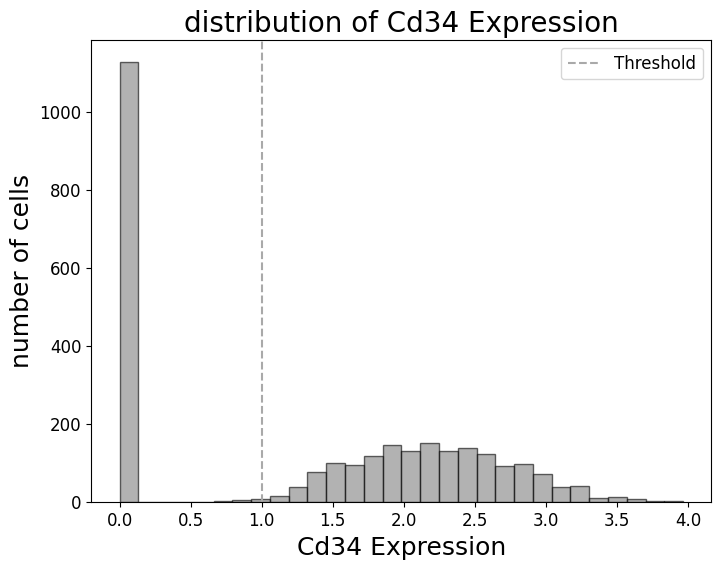

In [14]:
cd34_expression = adata_t1_clones_undiff[:, 'Cd34'].X.toarray().flatten()

# Plot the histogram of log-transformed Cd34 expression
plt.figure(figsize=(8, 6))
plt.hist(cd34_expression, bins=30, color='grey', edgecolor='black', alpha=0.6, density=False)
plt.axvline(x=1, linestyle = "--", label = "Threshold", c = "darkgrey")
plt.title('distribution of Cd34 Expression')
plt.xlabel('Cd34 Expression')
plt.legend()
plt.ylabel('number of cells')
plt.show()

### Assign undifferentiated cells high CD34 (day 2) cell-types based on future (day 4 and day 6) clonal cells' cell-type

In [15]:
# Initialize dictionary to store cell type counts and percentages for each clone_id
clone_cell_type = {}

# Loop through each unique clone_id
for clone_id in adata_t1_undiff_high_CD34.obs.clone_id.unique():
    # Get unique cell types for t2 and t3 as lists
    unique_t2_cell_types = adata_t2[adata_t2.obs.clone_id == clone_id].obs['Cell type annotation'].unique().tolist()
    unique_t3_cell_types = adata_t3[adata_t3.obs.clone_id == clone_id].obs['Cell type annotation'].unique().tolist()

    # Concatenate the lists and convert to a set (to avoid duplicates)
    cell_type = set(unique_t2_cell_types + unique_t3_cell_types)
    if len(cell_type) < 1:
        continue

    # Get the number of cells for each cell type at t2 and t3
    t2_cell_counts = adata_t2[adata_t2.obs.clone_id == clone_id].obs['Cell type annotation'].value_counts()
    t3_cell_counts = adata_t3[adata_t3.obs.clone_id == clone_id].obs['Cell type annotation'].value_counts()

    # Initialize dictionary to store counts and percentages
    cell_type_info = {}

    # Count and calculate percentages for t2
    total_cells_t2 = len(adata_t2[adata_t2.obs.clone_id == clone_id])
    for cell in cell_type:
        t2_count = t2_cell_counts.get(cell, 0)
        t2_percentage = (t2_count / total_cells_t2) * 100 if total_cells_t2 > 0 else 0
        cell_type_info[cell] = {'t2_count': t2_count, 't2_percentage': t2_percentage}

    # Count and calculate percentages for t3
    total_cells_t3 = len(adata_t3[adata_t3.obs.clone_id == clone_id])
    for cell in cell_type:
        t3_count = t3_cell_counts.get(cell, 0)
        t3_percentage = (t3_count / total_cells_t3) * 100 if total_cells_t3 > 0 else 0
        if cell in cell_type_info:
            cell_type_info[cell].update({'t3_count': t3_count, 't3_percentage': t3_percentage})
        else:
            cell_type_info[cell] = {'t3_count': t3_count, 't3_percentage': t3_percentage}

    # Store the information in the dictionary
    clone_cell_type[clone_id] = cell_type_info

# Convert the dictionary into a pandas DataFrame for easier inspection
cell_type_df = pd.DataFrame.from_dict({(clone_id, cell_type): values
                                       for clone_id, clone_info in clone_cell_type.items()
                                       for cell_type, values in clone_info.items()},
                                      orient='index')

# Display the DataFrame
print(cell_type_df)

                       t2_count  t2_percentage  t3_count  t3_percentage
3452 Meg                      0            0.0         2     100.000000
2542 Undifferentiated         2          100.0         3      33.333333
     Monocyte                 0            0.0         6      66.666667
565  Undifferentiated         2          100.0         0       0.000000
     Neutrophil               0            0.0         4     100.000000
...                         ...            ...       ...            ...
1119 Undifferentiated         0            0.0         4     100.000000
3980 Lymphoid                 1          100.0         0       0.000000
2489 Undifferentiated         1          100.0         3     100.000000
2987 Undifferentiated         3          100.0         0       0.000000
278  Undifferentiated         6          100.0         0       0.000000

[1154 rows x 4 columns]


In [16]:
# Initialize dictionaries
clone_dominant_cell_type = {}
clone_cell_type_composition = {}

# Loop through each clone_id and determine the dominant cell type(s) at t2 and t3
for clone_id, cell_type_info in clone_cell_type.items():

    dominant_cell_types = []

    # --- t2 dominant ---
    max_t2_percentage = max(cell_info['t2_percentage']
                            for cell_info in cell_type_info.values())
    dominant_cell_types_t2 = sorted([
        cell_type for cell_type, cell_info in cell_type_info.items()
        if cell_info['t2_percentage'] == max_t2_percentage
    ])

    # --- t3 dominant ---
    max_t3_percentage = max(cell_info['t3_percentage']
                            for cell_info in cell_type_info.values())
    dominant_cell_types_t3 = sorted([
        cell_type for cell_type, cell_info in cell_type_info.items()
        if cell_info['t3_percentage'] == max_t3_percentage
    ])

    # --- choose dominant timepoint ---
    if max_t2_percentage > max_t3_percentage:
        dominant_cell_types.extend(dominant_cell_types_t2)
        time_key = 't2_percentage'
    else:
        dominant_cell_types.extend(dominant_cell_types_t3)
        time_key = 't3_percentage'

    clone_dominant_cell_type[clone_id] = dominant_cell_types

    # --------------------------------------------------
    # NEW: store full composition string
    # --------------------------------------------------
    composition_parts = []
    for cell_type, info in cell_type_info.items():
        pct = info[time_key]
        if pct > 0:
            composition_parts.append(f"{cell_type}: {pct:.0f}%")

    clone_cell_type_composition[clone_id] = ", ".join(composition_parts)

# Now, assign the dominant cell type(s) to each clone in adata.obs
adata_t1_undiff_high_CD34.obs['dominant_cell_type'] = None
adata_t1_undiff_high_CD34.obs['cell_type_composition'] = None  # <-- NEW

for clone_id, dominant_cell_types in clone_dominant_cell_type.items():
    dominant_cell_type_str = dominant_cell_types[0]

    adata_t1_undiff_high_CD34.obs.loc[
        adata_t1_undiff_high_CD34.obs.clone_id == clone_id,
        'dominant_cell_type'
    ] = dominant_cell_type_str

    adata_t1_undiff_high_CD34.obs.loc[
        adata_t1_undiff_high_CD34.obs.clone_id == clone_id,
        'cell_type_composition'
    ] = clone_cell_type_composition[clone_id]


# Optionally, view the annotated data to ensure the clones are properly annotated
print(adata_t1_undiff_high_CD34.obs[['clone_id', 'dominant_cell_type', "cell_type_composition"]].drop_duplicates())

/tmp/ipykernel_3957034/1009383651.py:48: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_t1_undiff_high_CD34.obs['dominant_cell_type'] = None


                     clone_id dominant_cell_type   cell_type_composition
Cell barcode                                                            
AAACAAAC-ACGTATAC        3452                Meg               Meg: 100%
AAACAAAC-CCCTTCAG        4575               None                    None
AAACAAAC-CGACGTCA-1      2542   Undifferentiated  Undifferentiated: 100%
AAACAAAC-CTTACTCC-1      5781               None                    None
AAACAAAC-GCCTCTTT-2      5331               None                    None
...                       ...                ...                     ...
TGGGAATT-GGGAAGGT        2987   Undifferentiated  Undifferentiated: 100%
TGGTTAAC-TGCTATTT        2941               None                    None
TGTTATCA-AATCGGGT        3392               None                    None
TGTTATCA-CTTACTCC         278   Undifferentiated  Undifferentiated: 100%
TGTTATCA-GCCAAGAT-1      4407               None                    None

[1180 rows x 3 columns]


In [17]:
# Get the unique cell types in the 'dominant_cell_type' column
cell_type_list = adata_t1_undiff_high_CD34.obs['dominant_cell_type'].unique()

# Print the total number of cells
print(f"Number of cells: {adata_t1_undiff_high_CD34.shape[0]}")

# Print the number of cell types and list them
print(f"Number of cell types: {len(cell_type_list)}")
print(f"Cell types: {cell_type_list}")

# Count the number of cells in each cell type
cell_type_counts = adata_t1_undiff_high_CD34.obs['dominant_cell_type'].value_counts()

# Print the number of cells for each cell type
for cell_type, count in cell_type_counts.items():
    print(f"{cell_type}: {count}")



Number of cells: 1634
Number of cell types: 10
Cell types: ['Meg' None 'Undifferentiated' 'Neutrophil' 'Monocyte' 'Baso' 'Lymphoid'
 'Mast' 'Eos' 'Ccr7_DC']
Undifferentiated: 499
Monocyte: 201
Neutrophil: 119
Baso: 48
Lymphoid: 36
Meg: 4
Eos: 3
Mast: 2
Ccr7_DC: 2


### Volcano plot

In [21]:
def volcano_plot(
    adata,
    groupby,
    group,
    genes,
    pval_threshold=0.05,
    gene_list_Neutrophil=[],
    gene_list_monocyte=[],
    gene_list_ubi_exp=[]
    ):

    # -----------------------------
    # Subset data
    # -----------------------------
    adata_group1 = adata[adata.obs[groupby] == group]
    adata_group2 = adata[adata.obs[groupby] != group]

    logfc_list, pval_list, gene_group_list = [], [], []
    mean_g1_list, mean_g2_list = [], []

    for gene in genes:
        expr_group1 = np.expm1(adata_group1[:, gene].X.toarray()).flatten()
        expr_group2 = np.expm1(adata_group2[:, gene].X.toarray()).flatten()

        mean_group1 = np.mean(expr_group1)
        mean_group2 = np.mean(expr_group2)

        logfc = np.log2((mean_group1 + 1) / (mean_group2 + 1))
        logfc_list.append(logfc)
        mean_g1_list.append(mean_group1)
        mean_g2_list.append(mean_group2)

        _, pval = mannwhitneyu(expr_group1, expr_group2, alternative="two-sided")
        pval_list.append(pval)

        if gene in gene_list_Neutrophil:
            gene_group_list.append("Neutrophil")
        elif gene in gene_list_monocyte:
            gene_group_list.append("Monocyte")
        elif gene in gene_list_ubi_exp:
            gene_group_list.append("Regulatory TF")
        else:
            gene_group_list.append("Other")

    # -----------------------------
    # Results DataFrame
    # -----------------------------
    df_results = pd.DataFrame({
        "gene": genes,
        "mean_g1": mean_g1_list,
        "mean_g2": mean_g2_list,
        "logFC": logfc_list,
        "pval": pval_list,
        "gene_group": gene_group_list
    })

    df_results["neg_log10_pval"] = -np.log10(df_results["pval"] + 1e-10)
    df_results["significant"] = df_results["pval"] <= pval_threshold

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(8, 6))

    # Non-significant (grey)
    sns.scatterplot(
        data=df_results[~df_results["significant"]],
        x="logFC",
        y="neg_log10_pval",
        style="gene_group",
        markers={
            "Neutrophil": "s",
            "Monocyte": "D",
            "Regulatory TF": "^",
            "Other": "X"
        },
        color="lightgray",
        edgecolor=None,
        legend=False,
        clip_on=False,
        ax=ax
    )

    # Significant (colored)
    sns.scatterplot(
        data=df_results[df_results["significant"]],
        x="logFC",
        y="neg_log10_pval",
        hue="gene_group",
        style="gene_group",
        palette={
            "Neutrophil": "#56B4E9",
            "Monocyte": "#CC79A7",
            "Regulatory TF": "#009E73",
            "Other": "gray"
        },
        markers={
            "Neutrophil": "s",
            "Monocyte": "D",
            "Regulatory TF": "^",
            "Other": "X"
        },
    edgecolor='none',  # ← Change from None to 'none'
    linewidth=0,       # ← Add this for extra assurance
    clip_on=False,
    ax=ax
    )

    # -----------------------------
    # Text labels (no clipping)
    # -----------------------------
    texts = []
    for _, row in df_results[df_results["significant"]].iterrows():
        texts.append(
            ax.text(
                row["logFC"],
                row["neg_log10_pval"],
                row["gene"],
                fontsize=14,
                clip_on=False
            )
        )

    adjust_text(
    texts,
    ax=ax,
    move_only={'text': 'xy'},   # move labels only
    expand_text=(1.1, 1.1),    # minimal label–label repulsion
    expand_points=(1.0, 1.0),   # DO NOT push labels away from points
    force_text=(0.1, 0.4),      # gentle adjustment
    )

    # -----------------------------
    # Threshold line
    # -----------------------------
    ax.axhline(
        y=-np.log10(pval_threshold),
        color="green",
        linestyle="--",
        clip_on=False
    )

    # -----------------------------
    # Styling
    # -----------------------------
    sns.despine(ax=ax, right=True, top=True)
    ax.set_title(f"{group} vs rest")
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 p-value")

    ax.legend(
        title="Gene Groups",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=False
    )
    plt.show()

    return df_results

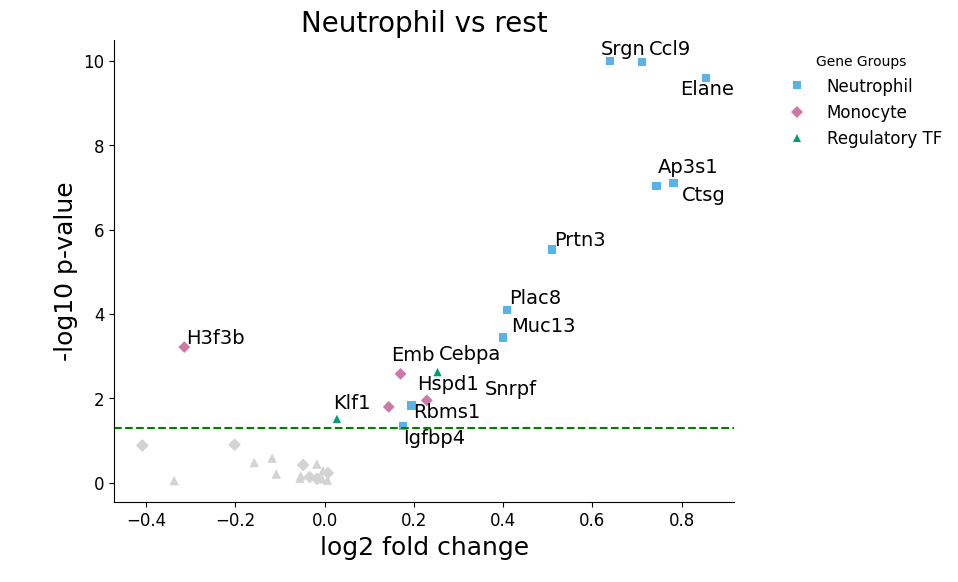

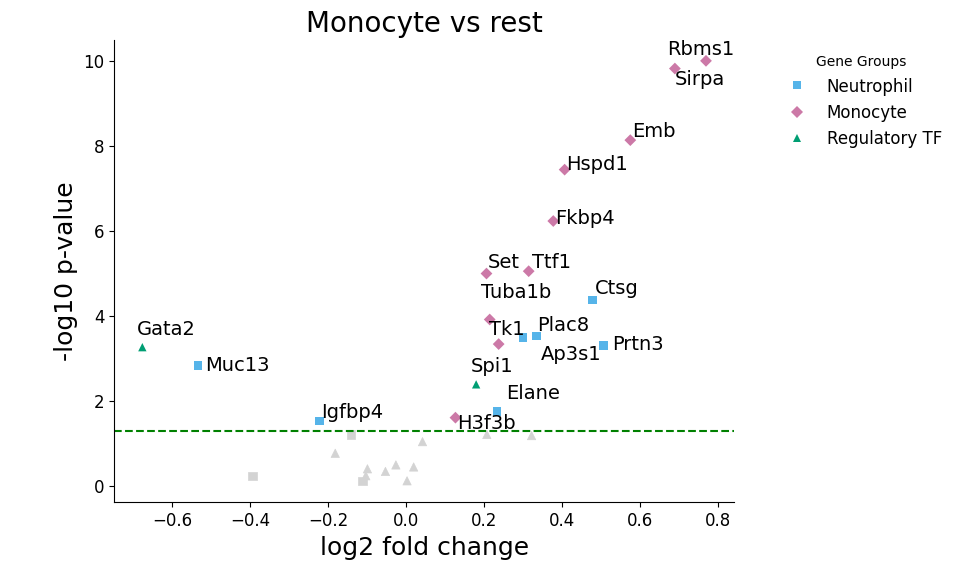

In [26]:
df_volcano_plot = {}
genes = gene_list_Neutrophil + gene_list_Monocyte + gene_list_Regulator_TF
cell_type_list = ["Neutrophil", "Monocyte"]
for cell_type in cell_type_list:
  if cell_type == "None":
    continue
  df_volcano_plot[cell_type] = volcano_plot(adata_t1_undiff_high_CD34, groupby='dominant_cell_type', group=cell_type, genes = genes, pval_threshold=0.05, gene_list_Neutrophil=gene_list_Neutrophil, gene_list_monocyte=gene_list_Monocyte, gene_list_ubi_exp=gene_list_Regulator_TF)
for cell_type in df_volcano_plot.keys():
    df = df_volcano_plot[cell_type]
    df.to_csv(f"{path_to_plot_data}/volcano_plot_{cell_type}_2.csv")

# Infer with TwINFER

In [56]:
# Drop column clone_id and rename pair_id to clone_id
t1_data.drop(columns=['clone_id'], inplace=True)
t1_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t2_data.drop(columns=['clone_id'], inplace=True)
t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t3_data.drop(columns=['clone_id'], inplace=True)
t3_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

across_t_data.drop(columns=['clone_id'], inplace=True)
across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t1_clones = t1_data.clone_id.values
t2_clones = t2_data.clone_id.values
t3_clones = t3_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t1_twins = t1_data
t2_twins = t2_data
t3_twins = t3_data

# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = across_t_data[across_t_data.time_step == t1]
across_t_twin2 = across_t_data[across_t_data.time_step == t2]

# Reset index for cleanliness
t1_twins = t1_twins.reset_index(drop=True)
t2_twins = t2_twins.reset_index(drop=True)
t3_twins = t3_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)

all_t1_t2_measurements = pd.concat(
[t1_twins, t2_twins, across_t_twin1, across_t_twin2],
ignore_index=True
)

all_t1_measurements = pd.concat(
[t1_twins, across_t_twin1],
ignore_index=True
)
all_t2_measurements = pd.concat(
[t2_twins, across_t_twin2],
ignore_index=True
)

all_t3_measurements = t3_twins

In [18]:
# Define input parameters
plot_correlation_matrices_as_heatmap = True
have_any_output = True
p_val_threshold_scrambled_gene_correlation = 0.01
show_scrambled_distribution_gene_correlation = False
z_score_threshold_two_states = 10

## Gene-gene correlation

In [ ]:
# --- Step 1: Pairwise gene-gene correlations at t1: day 2 ---
pairwise_gene_gene_correlation_matrix_t1 = calculate_pairwise_gene_gene_correlation_matrix(
    t1_data_all_cells, curr_gene_list
)
print(pairwise_gene_gene_correlation_matrix_t1)
no_regulation_t1, potential_regulation_t1, threshold = check_gene_gene_correlation_threshold(
    t1_data_all_cells, pairwise_gene_gene_correlation_matrix_t1, curr_gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation, n_cores_to_use=9
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Gene-gene correlations for {gene_set_name}", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self=True
    )

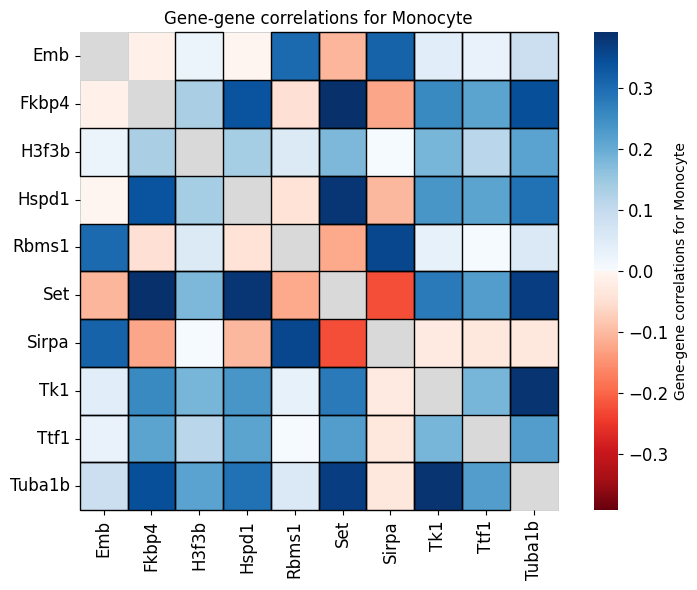

In [103]:
# --- Step 1: Pairwise gene-gene correlations at t2: day 4 ---
pairwise_gene_gene_correlation_matrix_t2 = calculate_pairwise_gene_gene_correlation_matrix(
    t2_data_all_cells, curr_gene_list
)
no_regulation_t2, potential_regulation_t2, _ = check_gene_gene_correlation_threshold(
    t2_data_all_cells, pairwise_gene_gene_correlation_matrix_t2, curr_gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation,  n_cores_to_use=9
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Gene-gene correlations for {gene_set_name}", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

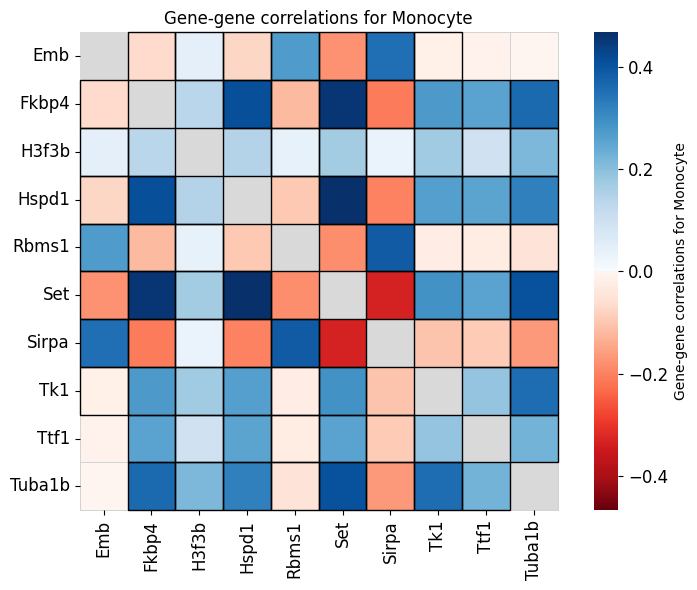

In [104]:
# --- Step 1: Pairwise gene-gene correlations at t3: day 4 ---
pairwise_gene_gene_correlation_matrix_t3 = calculate_pairwise_gene_gene_correlation_matrix(
    t3_data_all_cells, curr_gene_list
)
no_regulation_t3, potential_regulation_t3, _ = check_gene_gene_correlation_threshold(
    t3_data_all_cells, pairwise_gene_gene_correlation_matrix_t3, curr_gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation,  n_cores_to_use=9
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=curr_gene_list, no_regulation=no_regulation_t3, potential_regulation=potential_regulation_t3,
        title=f"Gene-gene correlations for {gene_set_name}", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

### Save the gene-gene correlation

In [105]:
# === Combine and save all timepoint results ===
rows = []

for tp, (no_reg, pot_reg, corr_mat) in {
    "t1": (no_regulation_t1, potential_regulation_t1, pairwise_gene_gene_correlation_matrix_t1),
    "t2": (no_regulation_t2, potential_regulation_t2, pairwise_gene_gene_correlation_matrix_t2),
    "t3": (no_regulation_t3, potential_regulation_t3, pairwise_gene_gene_correlation_matrix_t3),
}.items():

    all_pairs = set(tuple(sorted(p)) for p in no_reg + pot_reg)

    for g1, g2 in all_pairs:
        # lookup correlation (try both orders)
        if g1 in corr_mat.index and g2 in corr_mat.columns:
            corr_val = corr_mat.loc[g1, g2]
        elif g2 in corr_mat.index and g1 in corr_mat.columns:
            corr_val = corr_mat.loc[g2, g1]
        else:
            corr_val = None

        pair_sorted = tuple(sorted((g1, g2)))
        if pair_sorted in [tuple(sorted(p)) for p in pot_reg]:
            category = "potential_regulation"
        elif pair_sorted in [tuple(sorted(p)) for p in no_reg]:
            category = "no_regulation"
        else:
            category = "uncategorized"

        rows.append([g1, g2, corr_val, category, tp])

# Create DataFrame
df = pd.DataFrame(rows, columns=["gene_1", "gene_2", "correlation", "category", "timepoint"])

# Define output filename with timestamp
outfile = path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv"

# Save file
df.to_csv(outfile, index=False)

# Print confirmation with readable date/time
print(f"Saved {len(df)} pairs to {outfile.name}")

✅ [2025-12-13 23:52:42] Saved 135 pairs to gene_pair_results_Monocyte.csv


In [57]:
# === Load saved CSV ===
df = pd.read_csv(path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")


t1: 0 no-reg pairs, 45 potential-reg pairs, matrix (10, 10)
t2: 2 no-reg pairs, 43 potential-reg pairs, matrix (10, 10)
t3: 1 no-reg pairs, 44 potential-reg pairs, matrix (10, 10)


In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=False, gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, potential_regulation_t1, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1, single_state_regulation_t1)

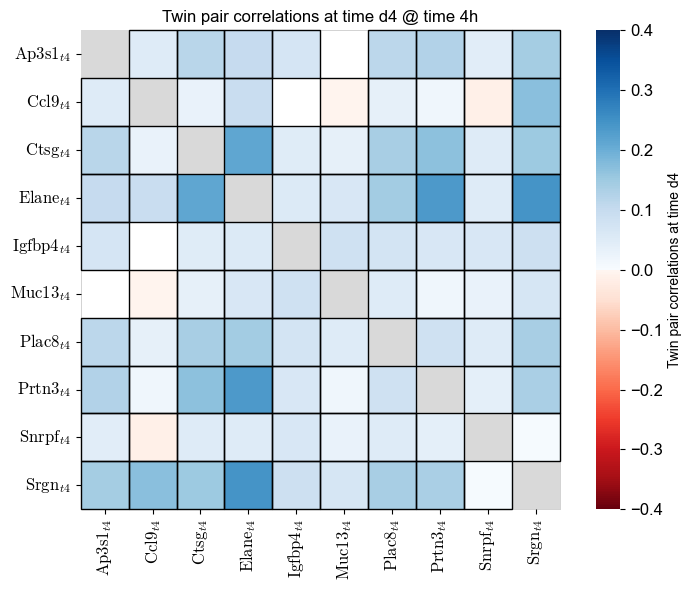

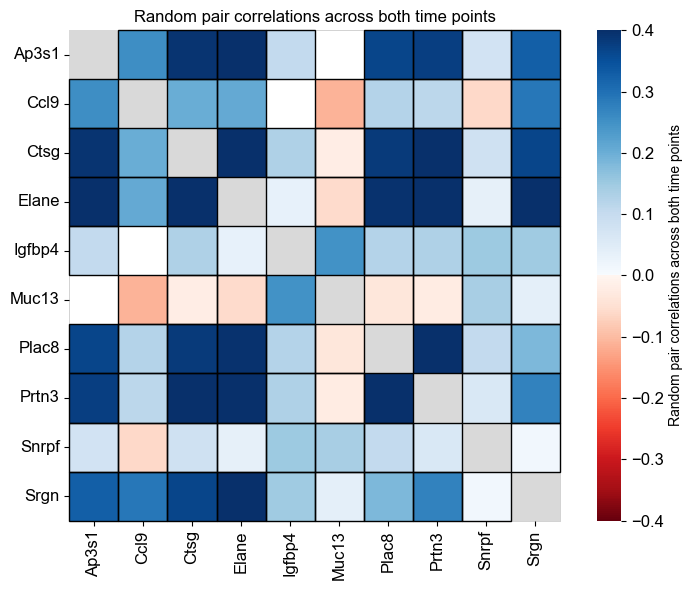

In [59]:
# --- Step 2: Twin/random correlations at day 4 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

In [ ]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [ ]:
# --- Step 4: Print summary of results ---
all_gene_pairs = list(product(curr_gene_list, repeat=2))
if have_any_output:
    print_summary(no_regulation_t1, single_state_regulation_t1, multiple_states_no_reg, multiple_states_and_reg)

In [63]:
# ----------------------------------
# Collect all classified pairs
# ----------------------------------
scenario_pair_lists = {
    "single-state, no regulation": no_regulation_t1,
    "single-state, regulation": single_state_regulation_t1,
    "multiple states, no regulation": multiple_states_no_reg,
    "multiple states, regulation": multiple_states_and_reg,
}

records = []

for scenario, pairs in scenario_pair_lists.items():
    for g1, g2 in pairs:
        g1, g2 = sorted((g1, g2))   # normalize
        records.append({
            "gene_1": g1,
            "gene_2": g2,
            "scenario": scenario,
            "timepoint": "t1"        # optional but strongly recommended
        })

df_pair_classification = pd.DataFrame(records)

# sanity check
assert not df_pair_classification.duplicated(
    ["gene_1", "gene_2", "timepoint"]
).any()

df_pair_classification.to_csv(f"{path_to_plot_data}/all_gene_pair_classification_{gene_set_name}.csv")

## Check for consistent correlated genes

In [ ]:
consistent_pairs = (
    set(potential_regulation_t1)
    & set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c1 = pairwise_gene_gene_correlation_matrix_t1.loc[g1, g2]
    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([c1, c2, c3])) or any(c == 0 for c in (c1, c2, c3)):
        continue

    if np.sign(c1) == np.sign(c2) == np.sign(c3):
        consistent_corr.append((g1, g2))
consistent_corr = sorted(consistent_corr)
print(len(consistent_corr))
consistent_corr

In [ ]:
#Plot all 3 timepoints highlight the consistent correlations
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 2", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 4", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene correlations at time day 6", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t1)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=True, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, potential_regulation_t1, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1, single_state_regulation_t1)


In [ ]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, black_out_self=True
    )

In [ ]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [145]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-regulation"
p_value_threshold_cross_correlation = 0.01
n_cores = 9

In [ ]:
if infer_direction_for_which_edges == "single-state" :
    if len(single_state_regulation_t1) > 0:
        bidirectional_pairs = {(a, b) for (a, b) in single_state_regulation_t1} | \
                  {(b, a) for (a, b) in single_state_regulation_t1}
        # Add self-pairs
        genes = {g for pair in single_state_regulation_t1 for g in pair}
        self_pairs = {(g, g) for g in genes}
        # Final
        all_gene_pairs = bidirectional_pairs | self_pairs
        all_gene_pairs = list(all_gene_pairs)
        direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)

        final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)

elif infer_direction_for_which_edges == "all-regulation":
    if len(single_state_regulation_t1) > 0 or len(multiple_states_and_reg):
            combined_list = single_state_regulation_t1 + multiple_states_and_reg
            bidirectional_pairs = {(a, b) for (a, b) in combined_list} | \
                  {(b, a) for (a, b) in combined_list}
            genes = {g for pair in single_state_regulation_t1 for g in pair}
            self_pairs = {(g, g) for g in genes}
            # Final
            all_gene_pairs_all_reg = bidirectional_pairs | self_pairs
            all_gene_pairs_all_reg = list(all_gene_pairs_all_reg)
            direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs_all_reg)
            final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs_all_reg, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
    else:
            final_directed_edges = []
            direction_matrix = pd.DataFrame(
                np.zeros((len(gene_list), len(gene_list))),
                index=gene_list,
                columns=curr_gene_list
            )
else:
    direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
    final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
print(final_directed_edges)
# print(pre_threshold_direction_matrix)
direction_matrix = direction_matrix.reindex(
index=curr_gene_list,
columns=curr_gene_list,
fill_value=0
)
unfiltered_direction_matrix = direction_matrix
if final_directed_edges:
    for i in direction_matrix.index:
        for j in direction_matrix.columns:
            if i != j and (i, j) not in final_directed_edges:
                direction_matrix.loc[i,j] = 0
if plot_correlation_matrices_as_heatmap and not direction_matrix.empty:
      all_gene_pairs = list(product(curr_gene_list, repeat=2))
      no_reg_pairs = [pair for pair in all_gene_pairs if pair not in final_directed_edges]
      if infer_direction_for_which_edges == "all-regulation" and multiple_states_and_reg:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False,
              draw_diagonal_multi_state_reg = True,
              multi_state_reg_edges = multiple_states_and_reg
          )
      else:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False
            )

In [47]:
import json

directional_gene_correlation_data = {
    "gene_list": list(curr_gene_list),
    "corr_matrix": direction_matrix.values.tolist(),
    "no_regulation_pairs": [list(p) for p in no_reg_pairs],
    "final_directed_edges": [list(p) for p in final_directed_edges],
    "multi_state_regulation_pairs": [list(p) for p in multiple_states_and_reg]
}

with open(f"{path_to_plot_data}/directional_gene_correlation_data.json", "w") as f:
    json.dump(directional_gene_correlation_data, f, indent=2)


## Twinfer analysis - but replacing clonal pairs with random pairs

In [81]:
#Twin pairs at each time point and across time point
use_undifferentiated = True
if use_undifferentiated:
    adata_t1 = adata_t1_clones_undiff.copy()
else:
    adata_t1 = adata_t1_all[(adata_t1_all.obs['clone_id'] != -1)].copy()

adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()

# Save cell IDs in .obs
adata_t1.obs['cell_id'] = adata_t1.obs_names
adata_t2.obs['cell_id'] = adata_t2.obs_names
adata_t3.obs['cell_id'] = adata_t3.obs_names

# RANDOMIZATION: Shuffle clone assignments while preserving distribution
np.random.seed(42)  # Set seed for reproducibility, remove or change as needed

def randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3):
    """
    Randomly reassign clone_ids to cells at each timepoint while preserving:
    - Clone size distribution at each timepoint
    - Which clones appear across timepoints (overlap structure)
    """
    # Get original clone IDs and their presence at each timepoint
    clones_t1 = set(adata_t1.obs['clone_id'].unique())
    clones_t2 = set(adata_t2.obs['clone_id'].unique())
    clones_t3 = set(adata_t3.obs['clone_id'].unique())
    
    # Identify clone categories
    all_clones = clones_t1.union(clones_t2).union(clones_t3)
    
    # Map each clone to which timepoints it appears in
    clone_timepoint_map = {}
    for clone_id in all_clones:
        appears_in = []
        if clone_id in clones_t1:
            appears_in.append('t1')
        if clone_id in clones_t2:
            appears_in.append('t2')
        if clone_id in clones_t3:
            appears_in.append('t3')
        clone_timepoint_map[clone_id] = tuple(appears_in)
    
    # Group clones by their timepoint pattern
    pattern_to_clones = {}
    for clone_id, pattern in clone_timepoint_map.items():
        if pattern not in pattern_to_clones:
            pattern_to_clones[pattern] = []
        pattern_to_clones[pattern].append(clone_id)
    
    # For each timepoint, randomize cell assignments within each pattern group
    for adata_t, timepoint in zip([adata_t1, adata_t2, adata_t3], ['t1', 't2', 't3']):
        # Shuffle cells
        shuffled_cells = adata_t.obs_names.to_numpy().copy()
        np.random.shuffle(shuffled_cells)
        
        new_clone_assignments = {}
        cell_idx = 0
        
        # For each pattern that includes this timepoint
        for pattern, clone_list in pattern_to_clones.items():
            if timepoint not in pattern:
                continue
            
            # For each clone in this pattern, assign cells maintaining clone size
            for clone_id in clone_list:
                clone_size = (adata_t.obs['clone_id'] == clone_id).sum()
                cells_for_clone = shuffled_cells[cell_idx:cell_idx + clone_size]
                for cell in cells_for_clone:
                    new_clone_assignments[cell] = clone_id
                cell_idx += clone_size
        
        adata_t.obs['clone_id'] = adata_t.obs_names.map(new_clone_assignments)
    
    return adata_t1, adata_t2, adata_t3

adata_t1, adata_t2, adata_t3 = randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3)

# CHECK: Verify that clonal structure is actually broken
def check_clonal_structure_broken(adata_original, adata_shuffled, timepoint):
    """Check that clone assignments have changed"""
    original_clones = adata_original.obs['clone_id'].values
    shuffled_clones = adata_shuffled.obs['clone_id'].values
    
    # Count how many cells kept their original clone assignment
    matches = (original_clones == shuffled_clones).sum()
    total = len(original_clones)
    match_pct = 100 * matches / total
    
    print(f"{timepoint}: {matches}/{total} cells ({match_pct:.2f}%) kept original clone assignment")
    
    # Check if any cells still have the same clone assignment
    if matches > 0:
        print(f"  WARNING: {matches} cells still in their original clones!")
    else:
        print(f"  ✓ All cells reassigned to different clones")
    
    return match_pct

# Store original clone assignments before randomization
adata_t1_original = adata_t1.copy()
adata_t2_original = adata_t2.copy()
adata_t3_original = adata_t3.copy()

# Note: Need to call randomization here after making copies
adata_t1, adata_t2, adata_t3 = randomize_clones_preserve_structure(adata_t1, adata_t2, adata_t3)

print("\n" + "="*60)
print("CLONAL STRUCTURE VERIFICATION")
print("="*60)
check_clonal_structure_broken(adata_t1_original, adata_t1, "t1")
check_clonal_structure_broken(adata_t2_original, adata_t2, "t2")
check_clonal_structure_broken(adata_t3_original, adata_t3, "t3")
print("="*60 + "\n")

# Pick subset of genes
gene_subset = [s + '_mRNA' for s in curr_gene_list]

# Create tables for t1, t2 and t3 twin pairs
for adata_t, timepoint in zip([adata_t1,adata_t2,adata_t3], ['t1','t2', 't3']):
    rows = []
    for clone_id, group in adata_t.obs.groupby('clone_id'):
        cells = group['cell_id'].tolist()
        pair_counter = 0
        for c1, c2 in itertools.combinations(cells, 2):
            pair_id = f"{clone_id}_p{pair_counter}_{timepoint}"
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c1,
                'replicate': 1
            })
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c2,
                'replicate': 2
            })
            pair_counter += 1

    if timepoint == 't1':
        t1_data = pd.DataFrame(rows)
    elif timepoint == 't2':
        t2_data = pd.DataFrame(rows)
    else:
        t3_data = pd.DataFrame(rows)

t1_data['time_step'] = np.repeat(t1, len(t1_data))
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t3_data['time_step'] = np.repeat(t3, len(t3_data))

t1_data[gene_subset] = adata_t1[t1_data.cell_id, curr_gene_list].X.toarray()
t2_data[gene_subset] = adata_t2[t2_data.cell_id, curr_gene_list].X.toarray()
t3_data[gene_subset] = adata_t3[t3_data.cell_id, curr_gene_list].X.toarray()

# ### Create tables for across t twin pairs
across_t_clones = list(set(adata_t1.obs.clone_id).intersection(adata_t2.obs.clone_id))
adata_t1_sub = adata_t1[adata_t1.obs.clone_id.isin(across_t_clones)]
adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]

rows_t1 = []
rows_t2 = []
for clone_id in across_t_clones:
    cells_t1 = adata_t1_sub[adata_t1_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    cells_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
    pair_counter = 0
    for cell_t1 in cells_t1:
        for cell_t2 in cells_t2:
            pair_id = f"{clone_id}_p{pair_counter}_across_t"
            rows_t1.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t1,
                'replicate': 1,
                'time_step': t1
            })
            rows_t2.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': cell_t2,
                'replicate': 2,
                'time_step': t2
            })

            pair_counter += 1

across_t_data_t1 = pd.DataFrame(rows_t1)
across_t_data_t2 = pd.DataFrame(rows_t2)

across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1.cell_id, curr_gene_list].X.toarray()
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, curr_gene_list].X.toarray()
across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data_t1.shape[0])}")


CLONAL STRUCTURE VERIFICATION
t1: 4/2770 cells (0.14%) kept original clone assignment
t2: 4/6121 cells (0.07%) kept original clone assignment
t3: 7/15978 cells (0.04%) kept original clone assignment

Number of t1 twins: 1576
Number of t2 twins: 7573
Number of t3 twins: 93203
Number of across t twins: 2981


In [82]:
# Drop column clone_id and rename pair_id to clone_id
t1_data.drop(columns=['clone_id'], inplace=True)
t1_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t2_data.drop(columns=['clone_id'], inplace=True)
t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t3_data.drop(columns=['clone_id'], inplace=True)
t3_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

across_t_data.drop(columns=['clone_id'], inplace=True)
across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t1_clones = t1_data.clone_id.values
t2_clones = t2_data.clone_id.values
t3_clones = t3_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t1_twins = t1_data
t2_twins = t2_data
t3_twins = t3_data

# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = across_t_data[across_t_data.time_step == t1]
across_t_twin2 = across_t_data[across_t_data.time_step == t2]

# Reset index for cleanliness
t1_twins = t1_twins.reset_index(drop=True)
t2_twins = t2_twins.reset_index(drop=True)
t3_twins = t3_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)

all_t1_t2_measurements = pd.concat(
[t1_twins, t2_twins, across_t_twin1, across_t_twin2],
ignore_index=True
)

all_t1_measurements = pd.concat(
[t1_twins, across_t_twin1],
ignore_index=True
)
all_t2_measurements = pd.concat(
[t2_twins, across_t_twin2],
ignore_index=True
)

all_t3_measurements = t3_twins

In [85]:
# === Load saved CSV ===
df = pd.read_csv(path_to_plot_data / f"gene_pair_results_{gene_set_name}.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")

consistent_pairs = (
    set(potential_regulation_t1)
    & set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c1 = pairwise_gene_gene_correlation_matrix_t1.loc[g1, g2]
    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([c1, c2, c3])) or any(c == 0 for c in (c1, c2, c3)):
        continue

    if np.sign(c1) == np.sign(c2) == np.sign(c3):
        consistent_corr.append((g1, g2))
consistent_corr = sorted(consistent_corr)
print(len(consistent_corr))


t1: 32 no-reg pairs, 34 potential-reg pairs, matrix (12, 12)
t2: 23 no-reg pairs, 43 potential-reg pairs, matrix (12, 12)
t3: 14 no-reg pairs, 52 potential-reg pairs, matrix (12, 12)
26


In [ ]:
# --- Step 2: Twin/random correlations at day 2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=False, gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=curr_gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, consistent_corr, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1)

In [ ]:
# --- Step 2: Twin/random correlations at day 4 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

In [92]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

Testing for multiple states. Correlation at time t1 = 0.021001168134420146 and at time t2 = 0.12476325503367669


['Cebpa', 'Egr1', 'Fli1', 'Gata1', 'Gata2', 'Gfi1b', 'Jun', 'Klf1', 'Nab2', 'Spi1', 'Tal1', 'Zfpm1']
Tal1 -> Zfpm1: threshold = 0.046957287227359416, actual = 0.010430495968244476
Cebpa -> Cebpa: threshold = 0.04704947235595513, actual = 0.004765847896505815
Gata1 -> Gfi1b: threshold = 0.04872256576066631, actual = 0.004679804587714546
Nab2 -> Nab2: threshold = 0.051039315661437615, actual = -0.0198350219669816
Tal1 -> Cebpa: threshold = 0.046729071441455564, actual = -0.013997504694337231
Klf1 -> Gata2: threshold = 0.046095129227664254, actual = -0.020132635126934053
Egr1 -> Tal1: threshold = 0.04656889599987483, actual = 0.0006276225540373012
Gfi1b -> Gata2: threshold = 0.04622538517187722, actual = -0.007211027421554487
Gata2 -> Klf1: threshold = 0.05026000137912577, actual = 0.0025838915954792385
Zfpm1 -> Tal1: threshold = 0.047451603268094736, actual = -0.018808437588369902
Gfi1b -> Gfi1b: threshold = 0.050154929824702904, actual = 0.0050394219851714155
Gata1 -> Egr1: threshold = 

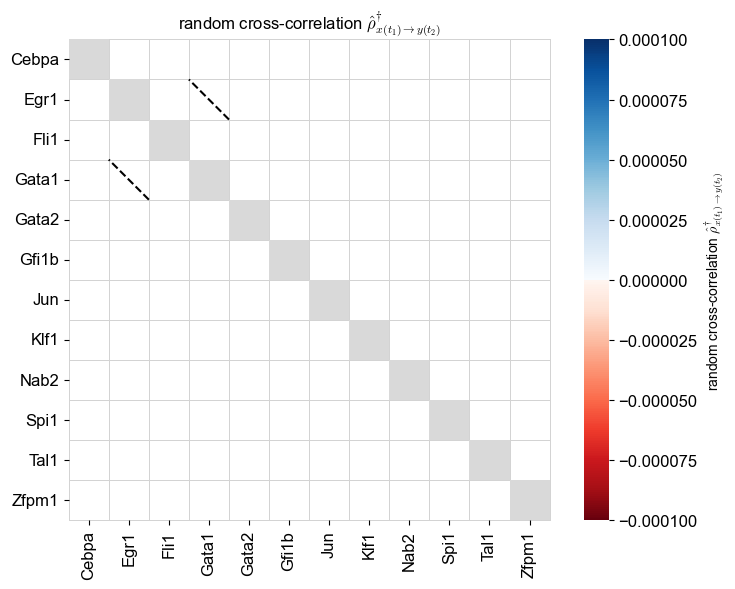

In [93]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-regulation"
p_value_threshold_cross_correlation = 0.01
n_cores = 9

if infer_direction_for_which_edges == "single-state" :
    if len(single_state_regulation_t1) > 0:
        bidirectional_pairs = {(a, b) for (a, b) in single_state_regulation_t1} | \
                  {(b, a) for (a, b) in single_state_regulation_t1}
        # Add self-pairs
        genes = {g for pair in single_state_regulation_t1 for g in pair}
        self_pairs = {(g, g) for g in genes}
        # Final
        all_gene_pairs = bidirectional_pairs | self_pairs
        all_gene_pairs = list(all_gene_pairs)
        direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)

        final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)

elif infer_direction_for_which_edges == "all-regulation":
    if len(single_state_regulation_t1) > 0 or len(multiple_states_and_reg):
            combined_list = single_state_regulation_t1 + multiple_states_and_reg
            bidirectional_pairs = {(a, b) for (a, b) in combined_list} | \
                  {(b, a) for (a, b) in combined_list}
            genes = {g for pair in single_state_regulation_t1 for g in pair}
            self_pairs = {(g, g) for g in genes}
            # Final
            all_gene_pairs_all_reg = bidirectional_pairs | self_pairs
            all_gene_pairs_all_reg = list(all_gene_pairs_all_reg)
            direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs_all_reg)
            final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs_all_reg, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
    else:
            final_directed_edges = []
            direction_matrix = pd.DataFrame(
                np.zeros((len(gene_list), len(gene_list))),
                index=gene_list,
                columns=curr_gene_list
            )
else:
    direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
    final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
print(final_directed_edges)
# print(pre_threshold_direction_matrix)
direction_matrix = direction_matrix.reindex(
index=curr_gene_list,
columns=curr_gene_list,
fill_value=0
)
unfiltered_direction_matrix = direction_matrix
if final_directed_edges:
    for i in direction_matrix.index:
        for j in direction_matrix.columns:
            if i != j and (i, j) not in final_directed_edges:
                direction_matrix.loc[i,j] = 0
if plot_correlation_matrices_as_heatmap and not direction_matrix.empty:
      all_gene_pairs = list(product(curr_gene_list, repeat=2))
      no_reg_pairs = [pair for pair in all_gene_pairs if pair not in final_directed_edges]
      if infer_direction_for_which_edges == "all-regulation" and multiple_states_and_reg:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"random cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False,
              draw_diagonal_multi_state_reg = True,
              multi_state_reg_edges = multiple_states_and_reg
          )
      else:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=curr_gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"random cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False
            )

In [94]:
import json

directional_gene_correlation_data = {
    "gene_list": list(curr_gene_list),
    "corr_matrix": direction_matrix.values.tolist(),
    "no_regulation_pairs": [list(p) for p in no_reg_pairs],
    "final_directed_edges": [list(p) for p in final_directed_edges],
    "multi_state_regulation_pairs": [list(p) for p in multiple_states_and_reg]
}

with open(f"{path_to_plot_data}/random_pair_directional_gene_correlation_data.json", "w") as f:
    json.dump(directional_gene_correlation_data, f, indent=2)


## Analyzing day 4 and day 6 data

In [23]:
#Twin pairs at each time point and across time point (SAME CELL TYPE ONLY)
adata_t2 = adata_t2_all[(adata_t2_all.obs['clone_id'] != -1)].copy()
adata_t3 = adata_t3_all[(adata_t3_all.obs['clone_id'] != -1)].copy()

# Save cell IDs in .obs
adata_t2.obs['cell_id'] = adata_t2.obs_names
adata_t3.obs['cell_id'] = adata_t3.obs_names

# Pick subset of genes
gene_subset = [s + '_mRNA' for s in curr_gene_list]

# ============================================================================
# Create tables for t2 and t3 twin pairs (SAME CELL TYPE WITHIN CLONE)
# ============================================================================

for adata_t, timepoint in zip([adata_t2, adata_t3], ['t2', 't3']):
    rows = []
    
    # Group by clone_id AND cell type
    for (clone_id, cell_type), group in adata_t.obs.groupby(['clone_id', 'Cell type annotation']):
        cells = group['cell_id'].tolist()
        
        # Only create pairs if there are at least 2 cells of this type
        if len(cells) < 2:
            continue
        
        pair_counter = 0
        for c1, c2 in itertools.combinations(cells, 2):
            pair_id = f"{clone_id}_{cell_type}_p{pair_counter}_{timepoint}"
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c1,
                'cell_type': cell_type,
                'replicate': 1
            })
            rows.append({
                'clone_id': clone_id,
                'pair_id': pair_id,
                'cell_id': c2,
                'cell_type': cell_type,
                'replicate': 2
            })
            pair_counter += 1

    if timepoint == 't2':
        t2_data = pd.DataFrame(rows)
    else:
        t3_data = pd.DataFrame(rows)

# Add time_step
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t3_data['time_step'] = np.repeat(t3, len(t3_data))

# Add gene expression data
t2_data[gene_subset] = adata_t2[t2_data.cell_id, curr_gene_list].X.toarray()
t3_data[gene_subset] = adata_t3[t3_data.cell_id, curr_gene_list].X.toarray()

# ============================================================================
# Create tables for across t2-t3 twin pairs (SAME CELL TYPE WITHIN CLONE)
# ============================================================================

across_t_clones = list(set(adata_t2.obs.clone_id).intersection(adata_t3.obs.clone_id))
adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]
adata_t3_sub = adata_t3[adata_t3.obs.clone_id.isin(across_t_clones)]

rows_t2 = []
rows_t3 = []

for clone_id in across_t_clones:
    clone_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id]
    clone_t3 = adata_t3_sub[adata_t3_sub.obs.clone_id == clone_id]
    
    # Get cell types present in BOTH timepoints for this clone
    t2_types = set(clone_t2.obs['Cell type annotation'].unique())
    t3_types = set(clone_t3.obs['Cell type annotation'].unique())
    common_types = t2_types.intersection(t3_types)
    
    # For each common cell type, create all possible pairs
    for cell_type in common_types:
        cells_t2 = clone_t2[clone_t2.obs['Cell type annotation'] == cell_type].obs['cell_id'].tolist()
        cells_t3 = clone_t3[clone_t3.obs['Cell type annotation'] == cell_type].obs['cell_id'].tolist()
        
        pair_counter = 0
        for cell_t2 in cells_t2:
            for cell_t3 in cells_t3:
                pair_id = f"{clone_id}_{cell_type}_p{pair_counter}_across_t2_t3"
                rows_t2.append({
                    'clone_id': clone_id,
                    'pair_id': pair_id,
                    'cell_id': cell_t2,
                    'cell_type': cell_type,
                    'replicate': 1,
                    'time_step': t2
                })
                rows_t3.append({
                    'clone_id': clone_id,
                    'pair_id': pair_id,
                    'cell_id': cell_t3,
                    'cell_type': cell_type,
                    'replicate': 2,
                    'time_step': t3
                })
                pair_counter += 1

across_t_data_t2 = pd.DataFrame(rows_t2)
across_t_data_t3 = pd.DataFrame(rows_t3)

# Add gene expression data
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, curr_gene_list].X.toarray()
across_t_data_t3[gene_subset] = adata_t3[across_t_data_t3.cell_id, curr_gene_list].X.toarray()

# Combine across timepoint data
across_t_data = pd.concat([across_t_data_t2, across_t_data_t3])

# ============================================================================
# SUMMARY
# ============================================================================
print(f"Number of t2 pairs (same cell type within clone): {int(t2_data.shape[0]/2):,}")
print(f"Number of t3 pairs (same cell type within clone): {int(t3_data.shape[0]/2):,}")
print(f"Number of across t2→t3 pairs (same cell type within clone): {int(across_t_data_t2.shape[0]):,}")

# Show breakdown by cell type for across timepoint pairs
print("\n--- Across t2→t3 pairs by cell type ---")
across_pairs_by_type = across_t_data_t2.groupby('cell_type').size().sort_values(ascending=False)
print(across_pairs_by_type)

/tmp/ipykernel_4066436/1197633377.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (clone_id, cell_type), group in adata_t.obs.groupby(['clone_id', 'Cell type annotation']):


Number of t2 pairs (same cell type within clone): 6,798
Number of t3 pairs (same cell type within clone): 67,975
Number of across t2→t3 pairs (same cell type within clone): 19,445

--- Across t2→t3 pairs by cell type ---
cell_type
Undifferentiated    17661
Baso                  744
Monocyte              605
Mast                  289
Neutrophil            116
Lymphoid               18
Eos                     9
Meg                     3
dtype: int64


In [32]:
# Drop column clone_id and rename pair_id to clone_id
t2_data.drop(columns=['clone_id'], inplace=True)
t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
t3_data.drop(columns=['clone_id'], inplace=True)
t3_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

across_t_data.drop(columns=['clone_id'], inplace=True)
across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t2_clones = t2_data.clone_id.values
t3_clones = t3_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t2_twins = t2_data
t3_twins = t3_data

# Across_t: separate by timepoint
# One cell per clone at t2
across_t_twin1 = across_t_data[across_t_data.time_step == t2]
# One cell per clone at t3
across_t_twin2 = across_t_data[across_t_data.time_step == t3]

# Reset index for cleanliness
t2_twins = t2_twins.reset_index(drop=True)
t3_twins = t3_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)

# Combine measurements
all_t2_t3_measurements = pd.concat(
    [t2_twins, t3_twins, across_t_twin1, across_t_twin2],
    ignore_index=True
)

all_t2_measurements = pd.concat(
    [t2_twins, across_t_twin1],
    ignore_index=True
)

all_t3_measurements = pd.concat(
    [t3_twins, across_t_twin2],
    ignore_index=True
)

# ============================================================================
# SUMMARY
# ============================================================================
print(f"\nData structure summary:")
print(f"t2_twins shape: {t2_twins.shape}")
print(f"t3_twins shape: {t3_twins.shape}")
print(f"across_t_twin1 (t2) shape: {across_t_twin1.shape}")
print(f"across_t_twin2 (t3) shape: {across_t_twin2.shape}")
print(f"\nCombined datasets:")
print(f"all_t2_measurements shape: {all_t2_measurements.shape}")
print(f"all_t3_measurements shape: {all_t3_measurements.shape}")
print(f"all_t2_t3_measurements shape: {all_t2_t3_measurements.shape}")

print(f"\nUnique clones in t2_twins: {t2_twins.clone_id.nunique()}")
print(f"Unique clones in t3_twins: {t3_twins.clone_id.nunique()}")
print(f"Unique clones in across_t: {across_t_twin1.clone_id.nunique()}")


Data structure summary:
t2_twins shape: (13596, 17)
t3_twins shape: (135950, 17)
across_t_twin1 (t2) shape: (19445, 17)
across_t_twin2 (t3) shape: (19445, 17)

Combined datasets:
all_t2_measurements shape: (33041, 17)
all_t3_measurements shape: (155395, 17)
all_t2_t3_measurements shape: (188436, 17)

Unique clones in t2_twins: 6798
Unique clones in t3_twins: 67975
Unique clones in across_t: 19445


### consistent gene correlations for day 4, day 6

In [31]:
import numpy as np

consistent_pairs = (
    set(potential_regulation_t2)
    & set(potential_regulation_t3)
)

consistent_corr_day_4_day_6 = []

for g1, g2 in consistent_pairs:
    # optional: enforce ordering to avoid (A,B) vs (B,A)
    g1, g2 = sorted((g1, g2))

    c2 = pairwise_gene_gene_correlation_matrix_t2.loc[g1, g2]
    c3 = pairwise_gene_gene_correlation_matrix_t3.loc[g1, g2]

    # ignore zero / NaN correlations
    if any(np.isnan([ c2, c3])) or any(c == 0 for c in (c2, c3)):
        continue

    if np.sign(c2) == np.sign(c3):
        consistent_corr_day_4_day_6.append((g1, g2))
consistent_corr_day_4_day_6 = sorted(consistent_corr_day_4_day_6)
print(len(consistent_corr_day_4_day_6))
consistent_corr_day_4_day_6


41


[('Cebpa', 'Fli1'),
 ('Cebpa', 'Gata2'),
 ('Cebpa', 'Jun'),
 ('Cebpa', 'Nab2'),
 ('Cebpa', 'Spi1'),
 ('Cebpa', 'Tal1'),
 ('Egr1', 'Gata1'),
 ('Egr1', 'Gata2'),
 ('Egr1', 'Gfi1b'),
 ('Egr1', 'Jun'),
 ('Egr1', 'Nab2'),
 ('Egr1', 'Tal1'),
 ('Egr1', 'Zfpm1'),
 ('Fli1', 'Gata1'),
 ('Fli1', 'Gata2'),
 ('Fli1', 'Klf1'),
 ('Fli1', 'Spi1'),
 ('Fli1', 'Tal1'),
 ('Gata1', 'Gata2'),
 ('Gata1', 'Gfi1b'),
 ('Gata1', 'Jun'),
 ('Gata1', 'Klf1'),
 ('Gata1', 'Nab2'),
 ('Gata1', 'Spi1'),
 ('Gata1', 'Tal1'),
 ('Gata1', 'Zfpm1'),
 ('Gata2', 'Gfi1b'),
 ('Gata2', 'Jun'),
 ('Gata2', 'Klf1'),
 ('Gata2', 'Nab2'),
 ('Gata2', 'Spi1'),
 ('Gata2', 'Tal1'),
 ('Gata2', 'Zfpm1'),
 ('Gfi1b', 'Tal1'),
 ('Gfi1b', 'Zfpm1'),
 ('Jun', 'Spi1'),
 ('Jun', 'Tal1'),
 ('Klf1', 'Tal1'),
 ('Nab2', 'Tal1'),
 ('Spi1', 'Zfpm1'),
 ('Tal1', 'Zfpm1')]

In [ ]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr_day_4_day_6,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=curr_gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr_day_4_day_6,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t2, single_state_regulation_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t2_measurements, consistent_corr_day_4_day_6, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t2, single_state_regulation_t2)

In [ ]:
# --- Step 2: Twin/random correlations at t3 ---
twin_pair_correlation_matrix_t3, random_pair_correlation_matrix_t3 = calculate_twin_random_pair_correlations(
    all_t3_measurements, t3_twins, curr_gene_list
)
# print(twin_pair_correlation_matrix_t3)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t3, gene_list=curr_gene_list, no_regulation=no_regulation_t3, potential_regulation=consistent_corr_day_4_day_6,
        title=f"Twin pair correlations at time d{t3}", add_gene_labels=True, add_time=False, gray_out_no_reg=True, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t3, gene_list=curr_gene_list, no_regulation=no_regulation_t3, potential_regulation=consistent_corr_day_4_day_6,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, gray_out_no_reg=True, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t3, single_state_regulation_t3 = differentiate_single_state_reg_and_multiple_states(
    all_t3_measurements, consistent_corr_day_4_day_6, twin_pair_correlation_matrix_t3, random_pair_correlation_matrix_t3, curr_gene_list, z_score_threshold=z_score_threshold_two_states
)

In [41]:
if len(multiple_states_gene_pairs_t2) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t2,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t2,
        random_pair_correlation_matrix_t3,multiple_states_gene_pairs_t3,curr_gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

Testing for multiple states. Correlation at time t1 = 0.03192784900974228 and at time t2 = 0.03192784900974228
Testing for multiple states. Correlation at time t1 = 0.014468299224993786 and at time t2 = 0.014468299224993786
Testing for multiple states. Correlation at time t1 = 0.00019655975640208947 and at time t2 = 0.00019655975640208947
Testing for multiple states. Correlation at time t1 = 0.023073121230599437 and at time t2 = 0.023073121230599437
Testing for multiple states. Correlation at time t1 = 0.021510929538449228 and at time t2 = 0.021510929538449228
Testing for multiple states. Correlation at time t1 = 0.08857879519519209 and at time t2 = 0.08857879519519209
Testing for multiple states. Correlation at time t1 = 0.07377857896846687 and at time t2 = 0.07377857896846687
Testing for multiple states. Correlation at time t1 = -0.012510073134889409 and at time t2 = -0.012510073134889409
Testing for multiple states. Correlation at time t1 = 0.004154239581716234 and at time t2 = 0.00

In [ ]:
# ============================================================================
# IDENTIFY ALL POSSIBLE CELL PAIRS (SAME TYPE, SAME CLONE)
# - Within t2 (day 4)
# - Within t3 (day 6)
# - Across t2→t3 (day 4 to day 6)
# ============================================================================

print("\n" + "="*70)
print("ALL POSSIBLE CELL PAIRS WITH SAME TYPE WITHIN CLONES")
print("="*70)

# Get common clones
clones_t2 = set(adata_t2.obs.clone_id.unique())
clones_t3 = set(adata_t3.obs.clone_id.unique())
common_clones = clones_t2.intersection(clones_t3)

clone_pair_details = []
total_pairs_within_t2 = 0
total_pairs_within_t3 = 0
total_pairs_across_t2_t3 = 0

for clone_id in common_clones:
    # Get all cells in this clone at both timepoints
    clone_t2 = adata_t2[adata_t2.obs.clone_id == clone_id]
    clone_t3 = adata_t3[adata_t3.obs.clone_id == clone_id]
    
    # Get cell type counts at each timepoint
    t2_type_counts = clone_t2.obs['Cell type annotation'].value_counts()
    t3_type_counts = clone_t3.obs['Cell type annotation'].value_counts()
    
    # Get all cell types
    all_types = set(t2_type_counts.index).union(set(t3_type_counts.index))
    
    # Calculate pairs for this clone
    clone_pairs_within_t2 = 0
    clone_pairs_within_t3 = 0
    clone_pairs_across = 0
    
    type_breakdown = {}
    
    for cell_type in all_types:
        n_t2 = t2_type_counts.get(cell_type, 0)
        n_t3 = t3_type_counts.get(cell_type, 0)
        
        # Within t2: pairs = n_t2 × (n_t2 - 1) / 2 (combinations)
        # Or if you want all ordered pairs: n_t2 × (n_t2 - 1)
        # Or if you want including self-pairs: n_t2 × n_t2
        # Let's use combinations (unordered pairs, excluding self): n × (n-1) / 2
        pairs_within_t2 = n_t2 * (n_t2 - 1) // 2 if n_t2 > 1 else 0
        
        # Within t3: same logic
        pairs_within_t3 = n_t3 * (n_t3 - 1) // 2 if n_t3 > 1 else 0
        
        # Across t2→t3: all possible pairings
        pairs_across = n_t2 * n_t3
        
        clone_pairs_within_t2 += pairs_within_t2
        clone_pairs_within_t3 += pairs_within_t3
        clone_pairs_across += pairs_across
        
        if pairs_within_t2 > 0 or pairs_within_t3 > 0 or pairs_across > 0:
            type_breakdown[cell_type] = {
                'n_t2': n_t2,
                'n_t3': n_t3,
                'pairs_within_t2': pairs_within_t2,
                'pairs_within_t3': pairs_within_t3,
                'pairs_across': pairs_across
            }
    
    total_pairs_within_t2 += clone_pairs_within_t2
    total_pairs_within_t3 += clone_pairs_within_t3
    total_pairs_across_t2_t3 += clone_pairs_across
    
    clone_pair_details.append({
        'clone_id': clone_id,
        'pairs_within_t2': clone_pairs_within_t2,
        'pairs_within_t3': clone_pairs_within_t3,
        'pairs_across_t2_t3': clone_pairs_across,
        'total_cells_t2': len(clone_t2),
        'total_cells_t3': len(clone_t3),
        'type_breakdown': type_breakdown
    })

print(f"\nTotal clones analyzed: {len(common_clones)}")
print(f"\n{'='*70}")
print("PAIR COUNTS")
print(f"{'='*70}")
print(f"Within day 4 (t2):           {total_pairs_within_t2:,} pairs")
print(f"Within day 6 (t3):           {total_pairs_within_t3:,} pairs")
print(f"Across day 4 → day 6 (t2→t3): {total_pairs_across_t2_t3:,} pairs")
print(f"\nTotal pairs (all):           {total_pairs_within_t2 + total_pairs_within_t3 + total_pairs_across_t2_t3:,} pairs")

# ============================================================================
# DETAILED BREAKDOWN BY CLONE
# ============================================================================

df_pairs = pd.DataFrame(clone_pair_details)

print("\n--- Top 20 clones by number of across-timepoint pairs ---")
print(df_pairs.sort_values('pairs_across_t2_t3', ascending=False)[
    ['clone_id', 'pairs_within_t2', 'pairs_within_t3', 'pairs_across_t2_t3', 
     'total_cells_t2', 'total_cells_t3']
].head(20))

# ============================================================================
# BREAKDOWN BY CELL TYPE
# ============================================================================

print("\n--- Pairs by cell type (across all clones) ---")
cell_type_summary = {}

for detail in clone_pair_details:
    for cell_type, counts in detail['type_breakdown'].items():
        if cell_type not in cell_type_summary:
            cell_type_summary[cell_type] = {
                'pairs_within_t2': 0,
                'pairs_within_t3': 0,
                'pairs_across': 0,
                'n_clones': 0,
                'total_t2_cells': 0,
                'total_t3_cells': 0
            }
        
        cell_type_summary[cell_type]['pairs_within_t2'] += counts['pairs_within_t2']
        cell_type_summary[cell_type]['pairs_within_t3'] += counts['pairs_within_t3']
        cell_type_summary[cell_type]['pairs_across'] += counts['pairs_across']
        cell_type_summary[cell_type]['n_clones'] += 1
        cell_type_summary[cell_type]['total_t2_cells'] += counts['n_t2']
        cell_type_summary[cell_type]['total_t3_cells'] += counts['n_t3']

df_cell_type_pairs = pd.DataFrame.from_dict(cell_type_summary, orient='index')
df_cell_type_pairs = df_cell_type_pairs.sort_values('pairs_across', ascending=False)
df_cell_type_pairs['total_pairs'] = (df_cell_type_pairs['pairs_within_t2'] + 
                                     df_cell_type_pairs['pairs_within_t3'] + 
                                     df_cell_type_pairs['pairs_across'])

print(df_cell_type_pairs[['n_clones', 'total_t2_cells', 'total_t3_cells', 
                          'pairs_within_t2', 'pairs_within_t3', 'pairs_across', 'total_pairs']])

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n--- Summary statistics by clone ---")
print(f"Mean pairs within t2 per clone:  {df_pairs['pairs_within_t2'].mean():.1f}")
print(f"Mean pairs within t3 per clone:  {df_pairs['pairs_within_t3'].mean():.1f}")
print(f"Mean pairs across t2→t3 per clone: {df_pairs['pairs_across_t2_t3'].mean():.1f}")

print(f"\nMedian pairs within t2 per clone:  {df_pairs['pairs_within_t2'].median():.1f}")
print(f"Median pairs within t3 per clone:  {df_pairs['pairs_within_t3'].median():.1f}")
print(f"Median pairs across t2→t3 per clone: {df_pairs['pairs_across_t2_t3'].median():.1f}")

# ============================================================================
# EXAMPLE: DETAILED VIEW OF ONE CLONE
# ============================================================================

# Show detailed breakdown for the clone with most across-timepoint pairs
example_clone = df_pairs.sort_values('pairs_across_t2_t3', ascending=False).iloc[0]
example_clone_id = example_clone['clone_id']

print(f"\n{'='*70}")
print(f"EXAMPLE: Clone {example_clone_id} (most across-timepoint pairs)")
print(f"{'='*70}")
print(f"Total cells at t2: {example_clone['total_cells_t2']}")
print(f"Total cells at t3: {example_clone['total_cells_t3']}")
print(f"Pairs within t2:   {example_clone['pairs_within_t2']:,}")
print(f"Pairs within t3:   {example_clone['pairs_within_t3']:,}")
print(f"Pairs across t2→t3: {example_clone['pairs_across_t2_t3']:,}")

example_detail = [d for d in clone_pair_details if d['clone_id'] == example_clone_id][0]
print("\nBreakdown by cell type:")
print(f"{'Cell Type':<20} {'t2 cells':>10} {'t3 cells':>10} {'Within t2':>12} {'Within t3':>12} {'Across':>12}")
print("-" * 80)
for cell_type, counts in example_detail['type_breakdown'].items():
    print(f"{cell_type:<20} {counts['n_t2']:>10} {counts['n_t3']:>10} "
          f"{counts['pairs_within_t2']:>12,} {counts['pairs_within_t3']:>12,} {counts['pairs_across']:>12,}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"Total clones: {len(common_clones)}")
print(f"\nPair definitions:")
print(f"  - Within timepoint: unordered pairs (combinations) of cells with same type")
print(f"    Formula: n × (n-1) / 2")
print(f"  - Across timepoints: all possible pairings of cells with same type")
print(f"    Formula: n_t2 × n_t3")
print(f"\nTotal pairs:")
print(f"  Within day 4 (t2):           {total_pairs_within_t2:>12,}")
print(f"  Within day 6 (t3):           {total_pairs_within_t3:>12,}")
print(f"  Across day 4 → day 6:        {total_pairs_across_t2_t3:>12,}")
print(f"  {'─'*40}")
print(f"  Grand total:                 {total_pairs_within_t2 + total_pairs_within_t3 + total_pairs_across_t2_t3:>12,}")